In [ ]:
# generate charts from /exp/*/log.csv

import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

def get_log_batch(experiment_path):
    # Get the path to the CSV file
    csv_file = os.path.join(experiment_path, 'log.csv')
    
    # Check if the CSV file exists
    if os.path.isfile(csv_file):
        frame = pd.read_csv(csv_file)
        return frame
    else:
        print(f"CSV file not found in {experiment_path}")
        return None

def single_experiment(experiment_path, y):
    # Load the CSV file into a DataFrame
    csv_file = os.path.join(experiment_path, 'log.csv')
    df = pd.read_csv(csv_file)

    #compare the learning curves (average return vs. number of environment steps)
    plt.figure(figsize=(10, 6))
    plt.plot(df['step'], df[y], label=f"Steps / {y}")
    plt.xlabel('Environment Steps')
    plt.ylabel(y)
    plt.title('Learning Curve')
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(experiment_path, f'learning_curve_{y}.png'))
    print(f"Saved learning curve for {experiment_path}")
    plt.close()

def plot_experiment(logs_dict, title, y='Eval_AverageReturn'):
    plt.figure(figsize=(10, 6))
    # different color for each experiment, with legend
    for exp_name, df in logs_dict.items():
        # skip rows where y empty
        df = df[df[y].notna()]
        plt.plot(df['step'], df[y], label=exp_name)

    plt.xlabel('steps')
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png')
    print(f"Saved plot: {title}")
    plt.close()
    # return plot

def plot_axes(log, title, ax = ['Eval_AverageReturn', 'Train_EpisodeReturn']):
    plt.figure(figsize=(10, 6))
    for a in ax:
        df = log[log[a].notna()]
        plt.plot(df['step'], df[a], label=a)
    plt.xlabel('steps')
    plt.ylabel('Return')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png')
    print(f"Saved plot: {title}")
    plt.close()

# Get a list of all small experiment directories
# regex: no _lb_ in the directory name
dir_names = glob.glob('exp/*/')

In [11]:
cart_dir_names = [d for d in dir_names if 'CartPole' in d]

# Stack plots for small and large batch size experiments separately
exps = dict()
for exp_dir in cart_dir_names:
    # drop all after 'sd' for name
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    exps[exp_name] = get_log_batch(exp_dir)
    # verify
    print(f"Loaded {len(exps[exp_name])} rows for {exp_name}")
plot_experiment(exps, 'Cartpole DQN', y='Eval_AverageReturn')


Processing exp\CartPole-v1_dqn_sd1_20260306_140920\
Using CartPole-v1_dqn
Loaded 1156 rows for CartPole-v1_dqn
Saved plot: Cartpole DQN


In [21]:
# Pacman
pacman_dirs = [d for d in dir_names if 'Pacman' in d]
lander_logs = dict()
for exp_dir in pacman_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    lander_logs[exp_name] = get_log_batch(exp_dir)
# plot_experiment(lander_logs, 'Pacman Double Q DQN', y='Eval_AverageReturn')
for exp_name, df in lander_logs.items():
    plot_axes(df, exp_name, ax = ['Train_EpisodeReturn', 'Eval_AverageReturn'])

Processing exp\MsPacman_dqn_sd1_20260307_131320\
Using MsPacman_dqn
Saved plot: MsPacman_dqn


In [22]:
# LunarLander
lander_baseline_dirs = [d for d in dir_names if 'LunarLander' in d and 'lr' not in d]
lander_logs = dict()
for exp_dir in lander_baseline_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    lander_logs[exp_name] = get_log_batch(exp_dir)
plot_experiment(lander_logs, 'LunarLander Double Q DQN', y='Eval_AverageReturn')

Processing exp\LunarLander-v2_dqn_sd1_20260306_230402\
Using LunarLander-v2_dqn
Saved plot: LunarLander Double Q DQN
Saved plot: LunarLander-v2_dqn_comparison


In [14]:
# LunarLander learning rate
lander_lr_dirs = [d for d in dir_names if 'LunarLander' in d and 'lr' in d]
lander_logs = dict()
for exp_dir in lander_lr_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    lander_logs[exp_name] = get_log_batch(exp_dir)
plot_experiment(lander_logs, 'LunarLander lr experiments', y='Eval_AverageReturn')

Processing exp\LunarLander-v2_dqn_lr1e-2_sd1_20260307_225439\
Using LunarLander-v2_dqn_lr1e-2
Processing exp\LunarLander-v2_dqn_lr1e-3_sd1_20260306_230402 - Copy\
Using LunarLander-v2_dqn_lr1e-3
Processing exp\LunarLander-v2_dqn_lr1e-4_sd1_20260307_231918\
Using LunarLander-v2_dqn_lr1e-4
Processing exp\LunarLander-v2_dqn_lr1e-5_sd1_20260308_003035\
Using LunarLander-v2_dqn_lr1e-5
Saved plot: LunarLander lr experiments


In [24]:
# cheetah
cheetah_baseline_dirs = [d for d in dir_names if 'Cheetah' in d and 'autotune' not in d]
cheetah_logs = dict()
for exp_dir in cheetah_baseline_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    cheetah_logs[exp_name] = get_log_batch(exp_dir)
plot_experiment(cheetah_logs, 'Half Cheetah SAC', y='Eval_AverageReturn')

Processing exp\HalfCheetah-v4_sac_sd1_20260308_115115\
Using HalfCheetah-v4_sac
Saved plot: Half Cheetah SAC


Processing exp\HalfCheetah-v4_sac_autotune_sd1_20260309_122840\
Using HalfCheetah-v4_sac_autotune
Processing exp\HalfCheetah-v4_sac_sd1_20260308_115115\
Using HalfCheetah-v4_sac
Saved plot: Half Cheetah eval return comparison
Processing exp\HalfCheetah-v4_sac_autotune_sd1_20260309_122840\
Using HalfCheetah-v4_sac_autotune


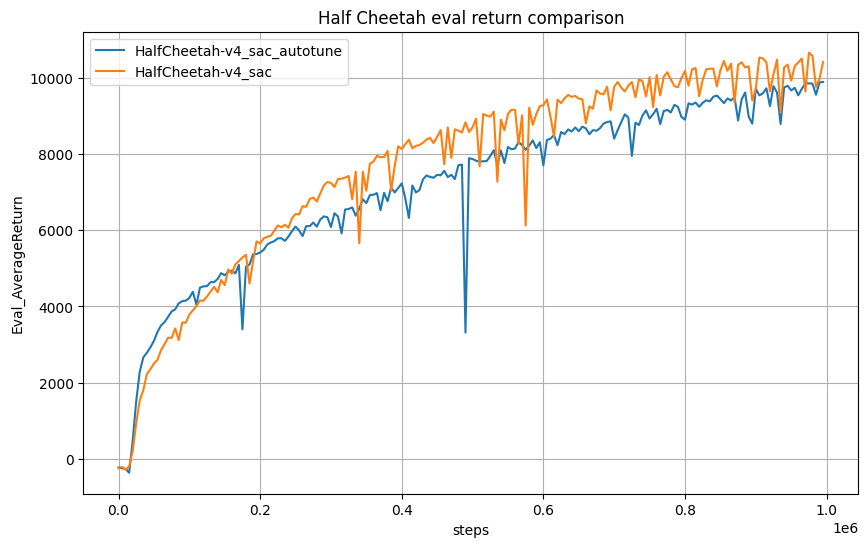

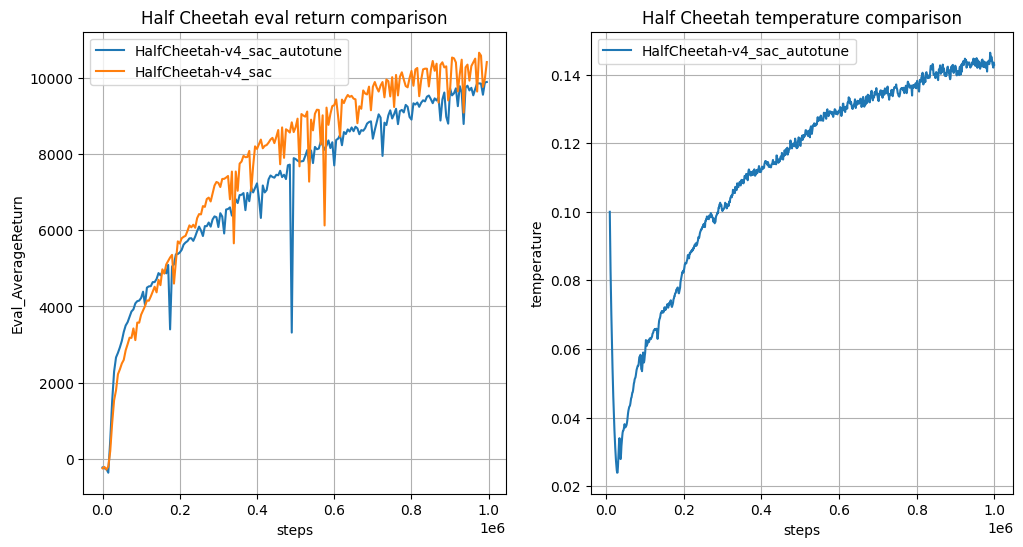

In [30]:
# cheetah autotune
cheetah_dirs = [d for d in dir_names if 'Cheetah' in d]
cheetah_logs = dict()
for exp_dir in cheetah_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    cheetah_logs[exp_name] = get_log_batch(exp_dir)
plot_experiment(cheetah_logs, 'Half Cheetah eval return comparison', y='Eval_AverageReturn')

cheetah_autotune_dirs = [d for d in dir_names if 'Cheetah' in d and 'autotune' in d]
cheetah_autotune_logs = dict()
for exp_dir in cheetah_autotune_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    cheetah_autotune_logs[exp_name] = get_log_batch(exp_dir)

# make plot with 2 subplots
# subplot 1: compare eval_averagereturn across cheetah_dirs
# subplot 2: chart temperature across cheetah_autotune_dirs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for exp_name, df in cheetah_logs.items():
    df = df[df['Eval_AverageReturn'].notna()]
    plt.plot(df['step'], df['Eval_AverageReturn'], label=exp_name)
plt.xlabel('steps')
plt.ylabel('Eval_AverageReturn')
plt.title('Half Cheetah eval return comparison')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
for exp_name, df in cheetah_autotune_logs.items():
    df = df[df['temperature'].notna()]
    plt.plot(df['step'], df['temperature'], label=exp_name)
plt.xlabel('steps')
plt.ylabel('temperature')
plt.title('Half Cheetah temperature comparison')
plt.legend()
plt.grid()
plt.savefig('half_cheetah_comparison.png')

In [25]:
# hopper
hopper_dirs = [d for d in dir_names if 'Hopper' in d]
hopper_logs = dict()
for exp_dir in hopper_dirs:
    print(f"Processing {exp_dir}")
    exp_name = exp_dir.split('\\')[-2].split('_sd')[0]
    print(f"Using {exp_name}")
    hopper_logs[exp_name] = get_log_batch(exp_dir)
plot_experiment(hopper_logs, 'Hopper eval', y='Eval_AverageReturn')
plot_experiment(hopper_logs, 'Hopper Q', y='q_values')

Processing exp\Hopper-v4_sac_clipq_sd1_20260309_233834\
Using Hopper-v4_sac_clipq
Processing exp\Hopper-v4_sac_singleq_sd1_20260309_215944\
Using Hopper-v4_sac_singleq
Saved plot: Hopper eval
Saved plot: Hopper Q
